In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

# 1. Loading and Preprocessing

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage



In [3]:
# Load the dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print("Shape:", df.shape)
print(df.head())

Shape: (150, 4)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


* The Iris dataset from sklearn does not include the species column within the feature dataset; it is provided separately as the target variable.
* Since clustering is an unsupervised learning method, the target variable is not used.
* Therefore, no explicit dropping is required, and only the feature data is used for clustering.

In [4]:
# Data Preprocessing
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# 2. Clustering Algorithm Implementation

# 2.1 KMeans Clustering

**Working of KMeans Clustering:**
* KMeans is an unsupervised machine learning algorithm that groups data into k distinct clusters based on feature similarity. The step by step working is:

1. **Choose k** — specify the number of clusters in advance. The optimal k will be determined using the Elbow Method and Silhouette Score before applying the algorithm. 
2. **Initialize centroids** — k centroids are placed using k-means++ initialization, which spreads them out smartly rather than randomly
3. **Assign points** — each data point is assigned to the nearest centroid based on Euclidean distance
4. **Recalculate centroids** — the centroid of each cluster is recalculated as the mean of all points assigned to it
5. **Repeat** — steps 3 and 4 repeat until the cluster assignments stop changing (convergence)

**Why KMeans is Suitable for the Iris Dataset:**
* Numeric features — all 4 features (sepal length, sepal width, petal length, petal width) are continuous numeric values, which work perfectly with distance-based calculations that KMeans relies on
* Compact clusters — The Iris data is expected to form compact, roughly spherical clusters in feature space — exactly the cluster shape KMeans handles best
* Clean data — the Iris dataset has no missing values or outliers, which means distance calculations are not distorted
* Small dataset — with only 150 samples KMeans converges quickly and efficiently
* Clear separation — The three species are expected to occupy distinct regions in feature space, particularly in petal length and petal width, making KMeans clustering highly effective

In [5]:
# Find optimal K - Elbow Method + Silhouette Score
inertia = []
sil_scores= []
k_range = range(2,11)

for k in k_range:
    km = KMeans(n_clusters=k, init ="k-means++", n_init=10, random_state= 42)
    labels = km.fit_predict(df_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(df_scaled, labels))

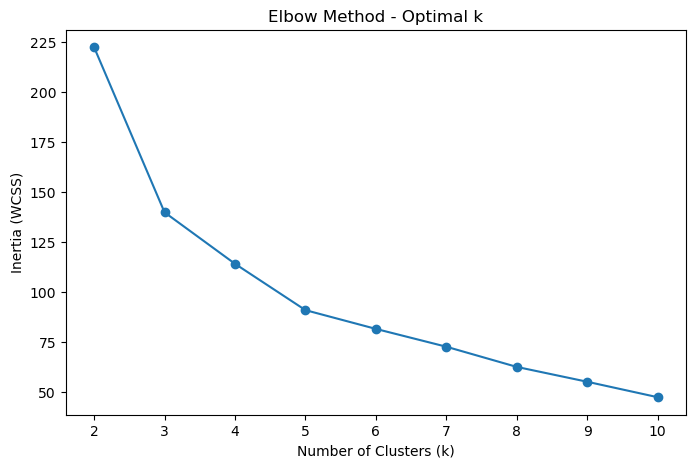

In [6]:
# Elbow plot
plt.figure(figsize= (8,5))
plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method - Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.xticks(k_range)
plt.show()

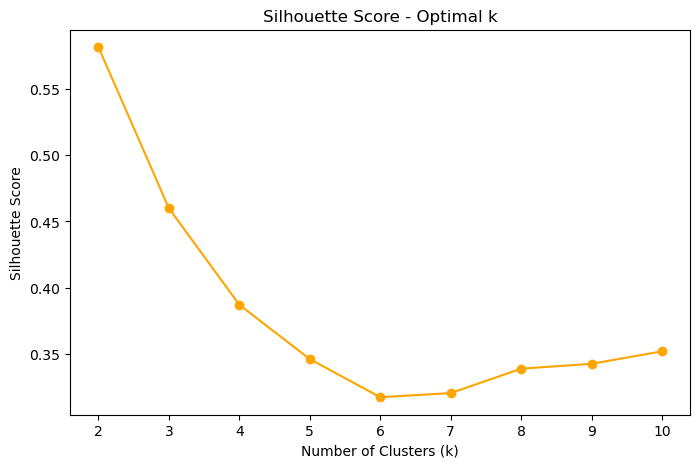

In [7]:
#Silhouette Score PLot
plt.figure(figsize=(8,5))
plt.plot(k_range, sil_scores, marker="o", color= "orange")
plt.title("Silhouette Score - Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.show()

* Both the Elbow Method and Silhouette Score were used to determine the optimal k. The Elbow plot shows a clear bend at k=3, indicating diminishing returns beyond that point. While the Silhouette Score peaks at k=2, the score at k=3 remains acceptable (≈0.46).
* Combined with domain knowledge of the Iris dataset having 3 species, k=3 was selected as the optimal number of clusters.

In [8]:
# Aplly KMeans with optimal k=3
kmeans= KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(df_scaled)
df['kmeans_labels'] = kmeans_labels
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),kmeans_labels
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [9]:
kmeans_score= silhouette_score(df_scaled, kmeans_labels)
print(f"KMeans Silhouette Score: {kmeans_score:.3f}")

KMeans Silhouette Score: 0.460


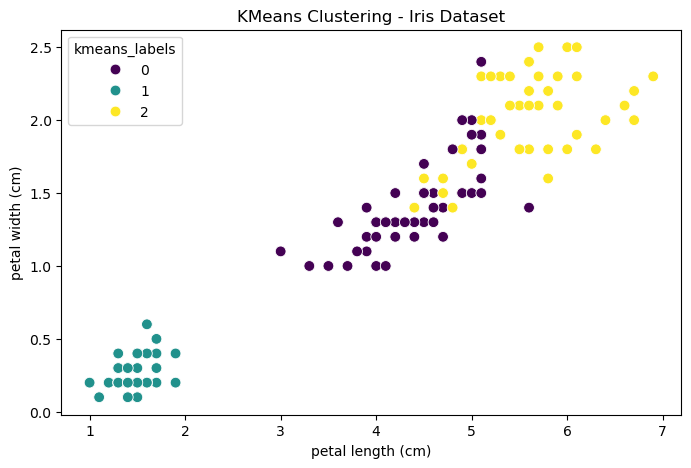

In [10]:
# visualization
plt.figure(figsize= (8,5))
sns.scatterplot(data=df,
               x= "petal length (cm)",
               y= "petal width (cm)",
               hue="kmeans_labels",
               palette= "viridis",
               s=60)
plt.title("KMeans Clustering - Iris Dataset")
plt.show()

* The 3 clusters are reasonably well separated
* Cluster 1 is the most distinct with zero overlap
* Clusters 0 and 2 have slight overlap — which is expected and also reflected in the silhouette score of ≈0.46 (good but not perfect)
* This confirms k=3 was the right choice for this dataset

# 2.2 Hierarchical Clustering

**Working of Heirarchical Clustering:**

Hierarchical clustering is an unsupervised machine learning algorithm that builds a tree-like structure of clusters called a dendrogram without needing to specify k in advance. It uses an agglomerative (bottom-up) approach:
1. **Start** — every data point is treated as its own individual cluster (150 clusters for Iris)
2. **Find closest pair** — the two most similar clusters are identified based on Euclidean distance
3. **Merge** — those two clusters are merged into one
4. **Repeat** — steps 2 and 3 repeat until all points are merged into a single cluster
5. **Cut the dendrogram** — a horizontal cut is made at an appropriate level to extract the desired number of clusters. The cut point is determined by looking for the largest vertical gap in the dendrogram
* The similarity between clusters is measured using Ward's linkage method, which minimizes the total within-cluster variance at each merge step — producing compact, well-defined clusters.

**Why Hierarchical Clustering is Suitable for the Iris Dataset:**
* No need to predefine k — unlike KMeans, the number of clusters does not need to be specified upfront; the dendrogram visually helps determine the optimal number of clusters
* Small dataset — with only 150 samples, hierarchical clustering is computationally feasible. It becomes expensive on large datasets, but Iris is well within its limits
* Ward's linkage works well — since all features are continuous and measured in the same unit (cm), Euclidean distance and Ward's linkage produce meaningful and compact cluster groupings
* Reveals cluster hierarchy — the dendrogram provides additional insight into how the three Iris species are related to each other at different levels of similarity, which KMeans cannot provide
* Numeric continuous features — all 4 features are continuous numeric values which work well with the distance calculations that hierarchical clustering relies on

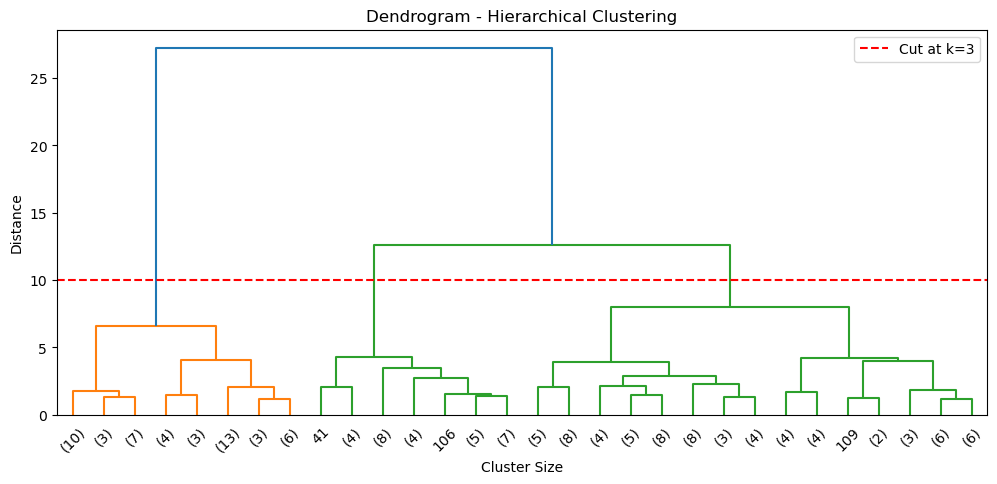

In [12]:
# Dendrogram
linked = linkage (df_scaled, method ="ward")

plt.figure(figsize=(12,5))
dendrogram(linked, truncate_mode="lastp", p=30)
plt.title("Dendrogram - Hierarchical Clustering")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.axhline(y=10, color="red", linestyle="--", label= "Cut at k=3")
plt.legend()
plt.show()

* The dendrogram reveals the hierarchical merging structure of the Iris dataset. The red dashed cut line at y=10 crosses 3 vertical lines, confirming that k=3 is the optimal number of clusters
* The left cluster merges at a low distance (≈7), indicating that these points are highly similar to each other. The remaining two clusters merge at a moderate distance (≈12), showing slight dissimilarity between them
* The largest vertical gap observed between y≈12 and y≈27 further validates k=3 as the optimal cut, as it represents the most significant jump in merging distance
* The two right side clusters are more similar to each other than either is to the left cluster, as they merge together at the highest level (y≈27)


In [13]:
# Apply Aglomerative Clustering
hier= AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
hier_labels= hier.fit_predict(df_scaled)

hier_score = silhouette_score(df_scaled, hier_labels)
print(f"Hierarchical Silhouette Score:{hier_score:.3f}")


Hierarchical Silhouette Score:0.447


* The Hierarchical Clustering achieved a Silhouette Score of 0.447, indicating that the clusters are reasonably well separated.
* Points within each cluster are fairly similar to each other and sufficiently different from points in neighboring clusters. While the score is not perfect, it reflects the slight overlap between two of the clusters, which is a characteristic of the data rather than a limitation of the algorithm.

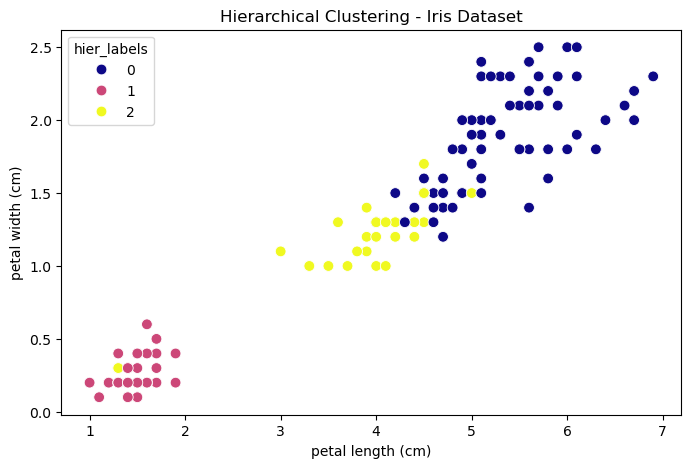

In [17]:
# Cluster plot
df["hier_labels"]= hier_labels

plt.figure(figsize=(8,5))
sns.scatterplot(data= df, 
               x="petal length (cm)",
               y="petal width (cm)",
               hue= "hier_labels",
               palette="plasma",
               s=60)
plt.title("Hierarchical Clustering - Iris Dataset")
plt.show()

* The scatter plot of petal length vs petal width reveals three distinct clusters.
* Cluster 1 (pink) occupies the bottom left region with small petal dimensions (length 1–2 cm, width 0–0.6 cm), and is perfectly separated with zero overlap from the other clusters
* Cluster 2 (yellow) occupies the middle region with moderate petal dimensions
* Cluster 0 (blue) occupies the right region with the largest petal dimensions
* A slight overlap exists between Cluster 2 and Cluster 0, which is consistent with the dendrogram observation that these two groups are more similar to each other compared to Cluster 1